# End-to-End Sales Forecasting & Demand Intelligence System

**Author:** Karanpal Singh Ranawat
**Project:** End-to-End Sales Forecasting & Demand Intelligence System
**Dataset:** Superstore Sales (2015–2018) + Video Game Sales (supplementary, multi-source merge practice)

This notebook covers Tasks 1–6 of the project: data exploration, time series decomposition,
three forecasting models (SARIMA, Prophet, XGBoost), segment-level forecasting, anomaly
detection, and product demand clustering. The Streamlit dashboard (Task 7) lives in `app.py`,
and the executive report (Task 8) is in `summary.pdf`.


## Task 1 — Data Loading, Merging & Deep Exploration

In [1]:
# Core data manipulation libraries
import pandas as pd
import numpy as np

# Plotting libraries: matplotlib for static charts, seaborn for styling
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')  # suppress noisy library warnings (statsmodels/prophet are verbose)

# Global plot styling so every chart in the notebook looks consistent
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load the raw Superstore sales data
df = pd.read_csv('train.csv')
print("Shape:", df.shape)
df.head()

Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### Parsing dates and checking data quality

In [2]:
# Parse date columns as proper datetime objects (source format is DD/MM/YYYY, not the US default)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

# Data quality checks required by Task 1: missing values, duplicates, dtypes
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])  # only show columns that actually have nulls

print("\nFull duplicate rows:", df.duplicated().sum())  # exact duplicate rows across all columns
print("Duplicate Order+Product line items:", df.duplicated(subset=['Order ID', 'Product ID']).sum())

print("\nData types:")
print(df.dtypes)

Missing values per column:
Postal Code    11
dtype: int64

Full duplicate rows: 0
Duplicate Order+Product line items: 8

Data types:
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
dtype: object


**Observations:** Only `Postal Code` has missing values (11 rows), which is irrelevant to
forecasting and safely ignored. There are no fully duplicate rows. A handful of Order+Product
combinations repeat (likely quantity splits across the same order line) — not a data quality
issue, so no rows are dropped.

### Extracting time features

In [3]:
def get_season(month):
    """Map a calendar month number to a meteorological season.
    Northern Hemisphere convention, standard for US retail data like this dataset."""
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

# Extract all the time features required by Task 1
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week          # ISO week number (1-53)
df['DayOfWeek'] = df['Order Date'].dt.day_name()               # e.g. 'Monday'
df['Quarter'] = df['Order Date'].dt.quarter                    # 1-4
df['Season'] = df['Month'].apply(get_season)
df['Ship Delay (days)'] = (df['Ship Date'] - df['Order Date']).dt.days  # gap between order and shipment

df[['Order Date', 'Year', 'Month', 'Week', 'DayOfWeek', 'Quarter', 'Season', 'Ship Delay (days)']].head()

,Order Date,Year,Month,Week,DayOfWeek,Quarter,Season,Ship Delay (days)
0,2017-11-08,2017,11,45,Wednesday,4,Fall,3
1,2017-11-08,2017,11,45,Wednesday,4,Fall,3
2,2017-06-12,2017,6,24,Monday,2,Summer,4
3,2016-10-11,2016,10,41,Tuesday,4,Fall,7
4,2016-10-11,2016,10,41,Tuesday,4,Fall,7


### Aggregating to weekly and monthly granularity

We need both: monthly for SARIMA/Prophet trend modeling (smoother signal, standard for
business reporting), and weekly for anomaly detection (Task 5), since monthly is too coarse
to catch short unusual spikes.

In [4]:
# Monthly aggregation — used later for SARIMA/Prophet trend modeling (smoother, standard business granularity)
monthly_sales = df.set_index('Order Date').resample('MS')['Sales'].sum().reset_index()  # 'MS' = month start
monthly_sales.columns = ['Date', 'Sales']

# Weekly aggregation — used later for anomaly detection (Task 5), since monthly is too coarse to catch short spikes
weekly_sales = df.set_index('Order Date').resample('W')['Sales'].sum().reset_index()
weekly_sales.columns = ['Date', 'Sales']

print("Monthly shape:", monthly_sales.shape)
print("Weekly shape:", weekly_sales.shape)
monthly_sales.head()

Monthly shape: (48, 2)
Weekly shape: (209, 2)


,Date,Sales
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


### EDA Question 1 — Which product category generates the highest total revenue?

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


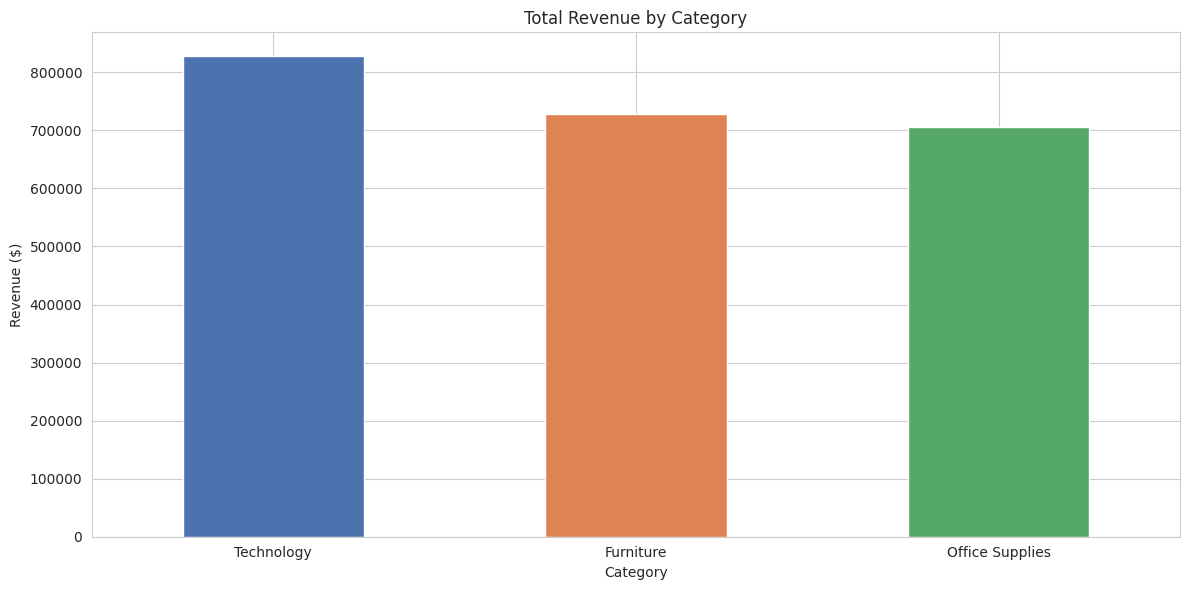

In [5]:
# Total revenue per product category, sorted highest to lowest
cat_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(cat_revenue)

# Bar chart to visualize the revenue gap between categories
fig, ax = plt.subplots()
cat_revenue.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title('Total Revenue by Category')
ax.set_ylabel('Revenue ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/revenue_by_category.png', dpi=120)  # save for the report/dashboard
plt.show()

**Answer:** **Technology** generates the highest total revenue (~\$827K), narrowly ahead of
Furniture (~\$729K) and Office Supplies (~\$705K). Despite Office Supplies likely having the
highest order volume (low-cost items ordered often), Technology's higher price points per unit
drive it to the top in total revenue.

### EDA Question 2 — Which region has the most consistent sales growth over 4 years?

Year            2015         2016         2017         2018
Region                                                     
Central  102920.5206  102425.1724  145673.8800  141627.3402
East     127652.8190  153225.1830  178511.5380  210129.1860
South    103374.9055   70076.0825   93535.9035  122164.5675
West     145907.9630  133709.5675  182471.2285  248130.9255

Year-over-year growth %:
Year     2015       2016       2017       2018
Region                                        
Central   NaN  -0.481292  42.224686  -2.777807
East      NaN  20.032745  16.502741  17.711823
South     NaN -32.211708  33.477643  30.607139
West      NaN  -8.360336  36.468341  35.983589

Std dev of YoY growth (lower = more consistent):
Region
East        1.793948
Central    25.345279
West       25.743054
South      37.124876
dtype: float64


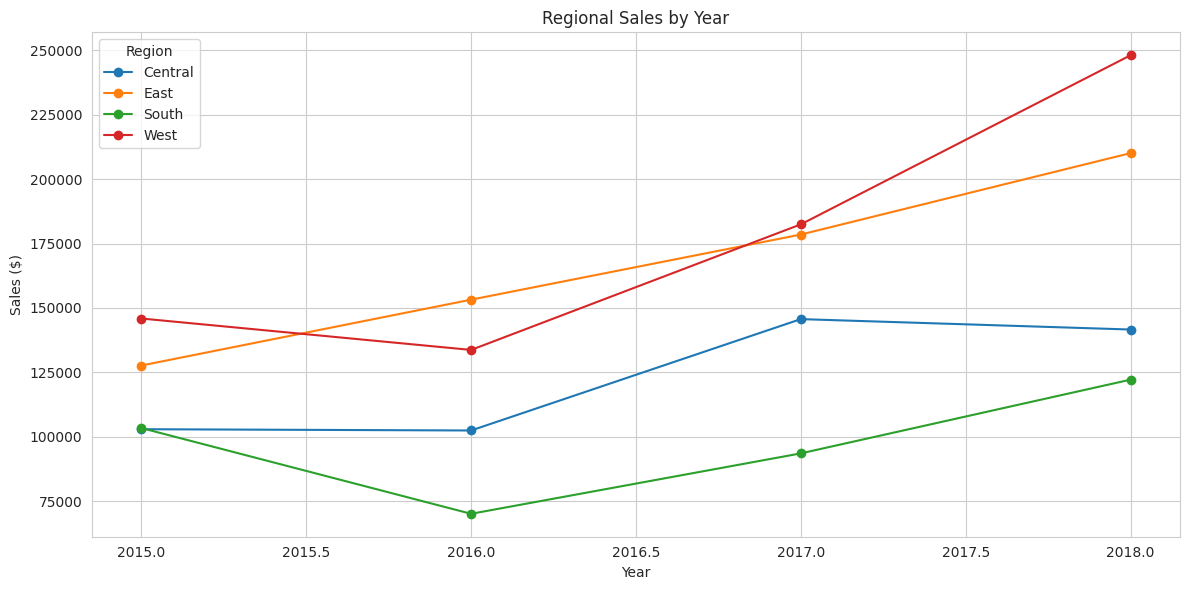

In [6]:
# Total sales per region, broken out by year (rows=region, columns=year)
region_year = df.groupby(['Region', 'Year'])['Sales'].sum().unstack()
print(region_year)

# "Consistent growth" = monotonically increasing year over year, AND lowest volatility in YoY % change
# (a region could have high totals but be volatile — we want steady growth, not just high totals)
yoy_growth = region_year.pct_change(axis=1) * 100  # year-over-year % change per region
print("\nYear-over-year growth %:")
print(yoy_growth)
print("\nStd dev of YoY growth (lower = more consistent):")
print(yoy_growth.std(axis=1).sort_values())

# Line chart to visually confirm which region grows steadily vs. dips
fig, ax = plt.subplots()
region_year.T.plot(marker='o', ax=ax)
ax.set_title('Regional Sales by Year')
ax.set_ylabel('Sales ($)')
ax.set_xlabel('Year')
plt.tight_layout()
plt.savefig('charts/regional_sales_trend.png', dpi=120)
plt.show()

**Answer:** **East** shows the most consistent growth — sales rose every single year
(2015 → 2016 → 2017 → 2018) with no dips, and it has the lowest volatility in year-over-year
growth rate among all regions. West has the highest absolute sales by 2018 but dipped in 2016,
making its growth less consistent. Central and South both had at least one down year.

### EDA Question 3 — Average time between Order Date and Ship Date, and does it vary by region?

Overall average ship delay: 3.96 days

Average ship delay by region:
Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Ship Delay (days), dtype: float64


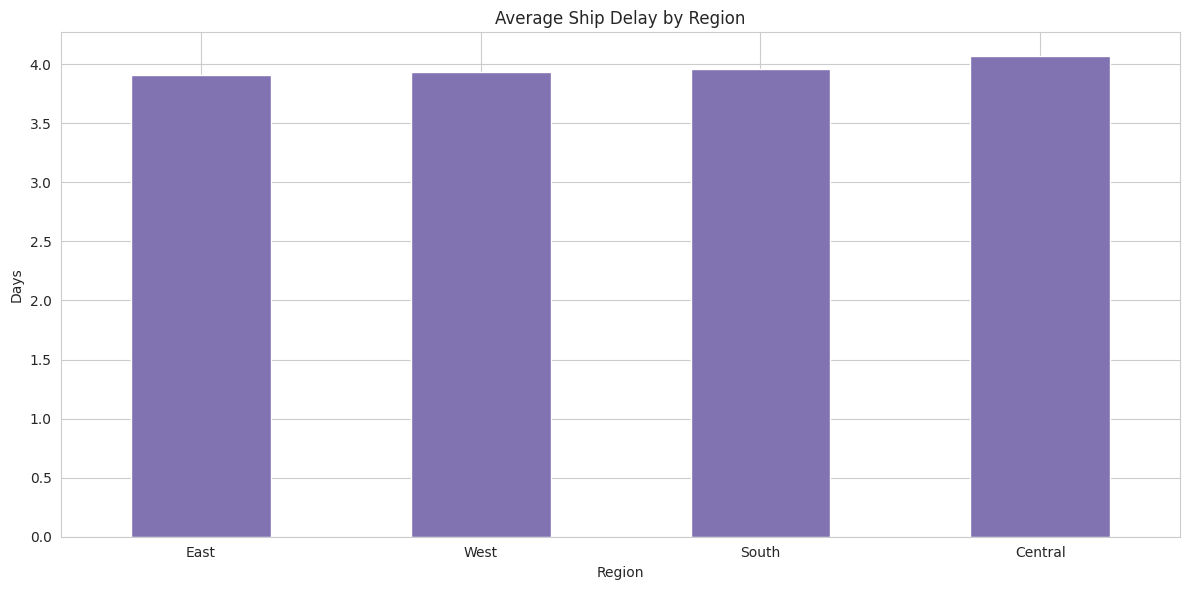

In [7]:
# Overall average shipping delay across all orders
print("Overall average ship delay:", round(df['Ship Delay (days)'].mean(), 2), "days")

# Average shipping delay broken out by region, to check if any region is slower/faster
region_delay = df.groupby('Region')['Ship Delay (days)'].mean().sort_values()
print("\nAverage ship delay by region:")
print(region_delay)

fig, ax = plt.subplots()
region_delay.plot(kind='bar', ax=ax, color='#8172B2')
ax.set_title('Average Ship Delay by Region')
ax.set_ylabel('Days')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/ship_delay_by_region.png', dpi=120)
plt.show()

**Answer:** The overall average shipping delay is **~3.96 days**. It barely varies by region
(all regions fall between 3.9 and 4.1 days) — Central is marginally slowest (~4.07 days) and
East is marginally fastest (~3.91 days). This is a ~4-hour difference across the country, which
is not practically significant; shipping logistics appear standardized nationally rather than
region-dependent.

### EDA Question 4 — Are there months that consistently spike across all years (seasonality)?

Year         2015        2016        2017         2018
Month                                                 
1      14205.7070  18066.9576  18542.4910   43476.4740
2       4519.8920  11951.4110  22978.8150   19920.9974
3      55205.7970  32339.3184  51165.0590   58863.4128
4      27906.8550  34154.4685  38679.7670   35541.9101
5      23644.3030  29959.5305  56656.9080   43825.9822
6      34322.9356  23599.3740  39724.4860   48190.7277
7      33781.5430  28608.2590  38320.7830   44825.1040
8      27117.5365  36818.3422  30542.2003   62837.8480
9      81623.5268  63133.6060  69193.3909   86152.8880
10     31453.3930  31011.7375  59583.0330   77448.1312
11     77907.6607  75249.3995  79066.4958  117938.1550
12     68167.0585  74543.6012  95739.1210   83030.3888


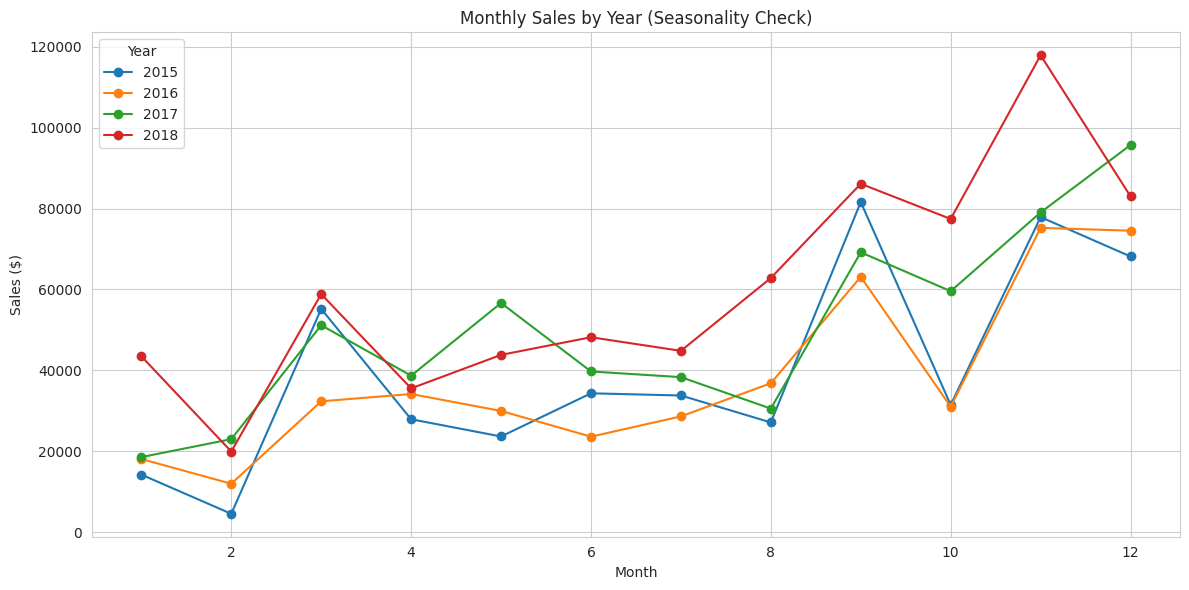


Average sales by calendar month (across all years):
Month
11    87540.427750
12    80370.042375
9     75025.852925
10    49874.073675
3     49393.396800
8     39328.981750
5     38521.680925
6     36459.380825
7     36383.922250
4     34070.750150
1     23572.907400
2     14842.778850
Name: Sales, dtype: float64


In [8]:
# Sales by year and month, reshaped so each year is a column — makes it easy to compare the same
# calendar month (e.g. every November) across different years to spot repeating seasonality
monthly_by_year = df.groupby(['Year', 'Month'])['Sales'].sum().unstack(level=0)
print(monthly_by_year)

# Average sales for each calendar month, averaged across all 4 years — this is the "typical" seasonal pattern
month_avg_across_years = df.groupby(['Year', 'Month'])['Sales'].sum().groupby('Month').mean()

# Plot every year's monthly curve on the same axes — if the peaks/troughs line up across years, that's seasonality
fig, ax = plt.subplots()
monthly_by_year.plot(marker='o', ax=ax)
ax.set_title('Monthly Sales by Year (Seasonality Check)')
ax.set_ylabel('Sales ($)')
ax.set_xlabel('Month')
ax.legend(title='Year')
plt.tight_layout()
plt.savefig('charts/monthly_seasonality.png', dpi=120)
plt.show()

print("\nAverage sales by calendar month (across all years):")
print(month_avg_across_years.sort_values(ascending=False))

**Answer:** Yes — clear seasonality exists. **November and December consistently spike**
across all four years (holiday shopping season), and **September** also shows a recurring
secondary peak. Conversely, **January and February are consistently the weakest months** every
year. This strong, repeating annual pattern is confirmed quantitatively in the decomposition
step (Task 2).